# Telco Customer Churn — EDA, Model Training & Evaluation

This notebook covers the **Stage 1** deliverable of the assessment: auditing and cleaning the
customer-churn dataset, exploring it, training a churn-risk model, and justifying the evaluation
metric. Every decision is documented next to the code that makes it. The exact same cleaning
logic and model pipeline live in the repo package (`src/churn_agent/`), where the agent uses the
model as a callable tool; this notebook is the readable, self-contained narrative of *why* it is
built that way.

## 0. Setup

Imports and reproducibility constants. Everything here is plain pandas / scikit-learn /
matplotlib — no exotic dependencies, per the brief.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_STATE = 42
pd.set_option("display.max_columns", 25)
print("pandas", pd.__version__)

pandas 3.0.5


## 1. Load the data

Works both locally (repo checkout) and on Google Colab: try the repo-relative path first,
otherwise download the CSV straight from the public GitHub repository.

In [2]:
from pathlib import Path

LOCAL = Path("../data/Customer-Churn.csv")
RAW_URL = "https://raw.githubusercontent.com/ahmad9022032/autonomous-churn-analyst/main/data/Customer-Churn.csv"

raw = pd.read_csv(LOCAL if LOCAL.exists() else RAW_URL)
print(raw.shape)
raw.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Data audit — figuring out what's wrong

The brief deliberately doesn't say what's wrong with the file. So before touching anything we
run a broad audit: dtypes, missing values, duplicates, whitespace, category domains, numeric
ranges, and cross-field consistency.

In [3]:
raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

**Finding 1 — `TotalCharges` loaded as text.** Every other numeric column parsed fine, so
something inside `TotalCharges` isn't a number. Let's find the offending values.

In [4]:
non_numeric_mask = pd.to_numeric(raw["TotalCharges"], errors="coerce").isna()
offending = raw.loc[non_numeric_mask, ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]]
print(f"{len(offending)} non-numeric TotalCharges values, repr of one: {raw.loc[non_numeric_mask, 'TotalCharges'].iloc[0]!r}")
offending

11 non-numeric TotalCharges values, repr of one: ' '


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


All 11 bad values are a **single space**, and every one belongs to a `tenure = 0` customer with
`Churn = "No"`. These are brand-new customers who have never been billed — the blank is a
*structural* missing value, not data corruption. That drives the cleaning decision in section 3.

In [5]:
assert (raw.loc[non_numeric_mask, "tenure"] == 0).all()
assert (raw.loc[non_numeric_mask, "Churn"] == "No").all()
assert (raw["tenure"] == 0).sum() == non_numeric_mask.sum()  # they are ALL the tenure-0 rows
print("Confirmed: the 11 blanks are exactly the tenure=0 (never-billed) customers.")

Confirmed: the 11 blanks are exactly the tenure=0 (never-billed) customers.


**Finding 2 — `SeniorCitizen` is encoded 0/1** while every other yes/no column uses the strings
`Yes`/`No`. Harmless for a model, but inconsistent for humans and for an agent writing filters —
we normalize it.

In [6]:
binary_cols = ["Partner", "Dependents", "PhoneService", "PaperlessBilling", "Churn"]
print({c: sorted(raw[c].unique()) for c in binary_cols})
print("SeniorCitizen:", sorted(raw["SeniorCitizen"].unique()))

{'Partner': ['No', 'Yes'], 'Dependents': ['No', 'Yes'], 'PhoneService': ['No', 'Yes'], 'PaperlessBilling': ['No', 'Yes'], 'Churn': ['No', 'Yes']}
SeniorCitizen: [np.int64(0), np.int64(1)]


**Null-result audit.** Knowing what *isn't* wrong matters as much as what is. We check
duplicates, whitespace, category domains, numeric ranges, service-flag cross-consistency, and
whether `TotalCharges` is consistent with `tenure x MonthlyCharges`. Everything below comes back
clean — this file is the pristine classic Telco dataset apart from the two findings above.

In [7]:
checks = {}
checks["duplicate rows"] = int(raw.duplicated().sum())
checks["duplicate customerIDs"] = int(raw["customerID"].duplicated().sum())
obj_cols = [c for c in raw.columns if not pd.api.types.is_numeric_dtype(raw[c])]
checks["values with stray whitespace (excl. TotalCharges)"] = int(sum(
    (raw[c].astype(str) != raw[c].astype(str).str.strip()).sum() for c in obj_cols if c != "TotalCharges"
))
checks["negative tenure/charges"] = int((raw["tenure"] < 0).sum() + (raw["MonthlyCharges"] <= 0).sum())

no_internet = raw["InternetService"] == "No"
sub_services = ["OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"]
checks["service-flag inconsistencies"] = int(sum(
    ((raw[c] == "No internet service") != no_internet).sum() for c in sub_services
) + ((raw["MultipleLines"] == "No phone service") != (raw["PhoneService"] == "No")).sum())

tc = pd.to_numeric(raw["TotalCharges"], errors="coerce")
billed = raw["tenure"] > 0
ratio = tc[billed] / (raw.loc[billed, "tenure"] * raw.loc[billed, "MonthlyCharges"])
checks["TotalCharges wildly off tenure*MonthlyCharges (ratio <0.4 or >2)"] = int(((ratio < 0.4) | (ratio > 2)).sum())

pd.Series(checks, name="count of problems found")

duplicate rows                                                      0
duplicate customerIDs                                               0
values with stray whitespace (excl. TotalCharges)                   0
negative tenure/charges                                             0
service-flag inconsistencies                                        0
TotalCharges wildly off tenure*MonthlyCharges (ratio <0.4 or >2)    0
Name: count of problems found, dtype: int64

## 3. Cleaning

Two fixes, both minimal and reversible in intent:

1. **Impute `TotalCharges = 0.0` for the 11 never-billed customers** (and cast the column to
   float). Zero is the *semantically true* amount billed so far — not a statistical guess — and
   keeping the rows means every count the agent later computes matches the source file exactly.
   The alternative (dropping 11 of 7043 rows, 0.16%) would be defensible for pure modeling but
   silently desynchronizes counts, which is poison for a system graded on numeric traceability.
2. **Map `SeniorCitizen` 0/1 → No/Yes** for consistency with every other binary column.

`customerID` stays as a lookup column but will be excluded from model features.

In [8]:
df = raw.copy()
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce").fillna(0.0)
df["SeniorCitizen"] = df["SeniorCitizen"].map({0: "No", 1: "Yes"})

assert df.notna().all().all(), "cleaning left missing values"
assert len(df) == 7043
print("Clean. Shape:", df.shape)
df[["SeniorCitizen", "TotalCharges"]].describe(include="all").T

Clean. Shape: (7043, 21)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043,2,No,5901,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TotalCharges,7043.0,NaN,NaN,NaN,2279.734304,2266.79447,0.0,398.55,1394.55,3786.6,8684.8


## 4. EDA — target

26.54% of customers churned. That imbalance (roughly 1:2.8) is mild but real, and it is the
main reason plain accuracy will be rejected as an evaluation metric later: predicting "nobody
churns" already scores 73.5%.

Churn rate: 26.54%  (1869 of 7043)


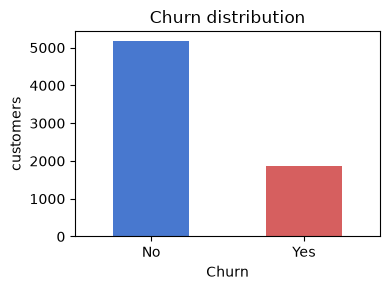

In [9]:
churn_rate = (df["Churn"] == "Yes").mean()
print(f"Churn rate: {churn_rate:.2%}  ({(df['Churn'] == 'Yes').sum()} of {len(df)})")

fig, ax = plt.subplots(figsize=(4, 3))
df["Churn"].value_counts().plot.bar(ax=ax, color=["#4878CF", "#D65F5F"], rot=0)
ax.set_title("Churn distribution")
ax.set_ylabel("customers")
plt.tight_layout()

## 5. EDA — churn vs. contract, internet service, payment method

Contract type is the strongest single driver visible to the eye: month-to-month customers churn
at ~43%, two-year customers at under 3%. Fiber-optic internet and electronic-check payment also
stand out — patterns the model should later confirm as top factors.

Contract
Month-to-month    0.4271
One year          0.1127
Two year          0.0283
Name: Churn, dtype: float64

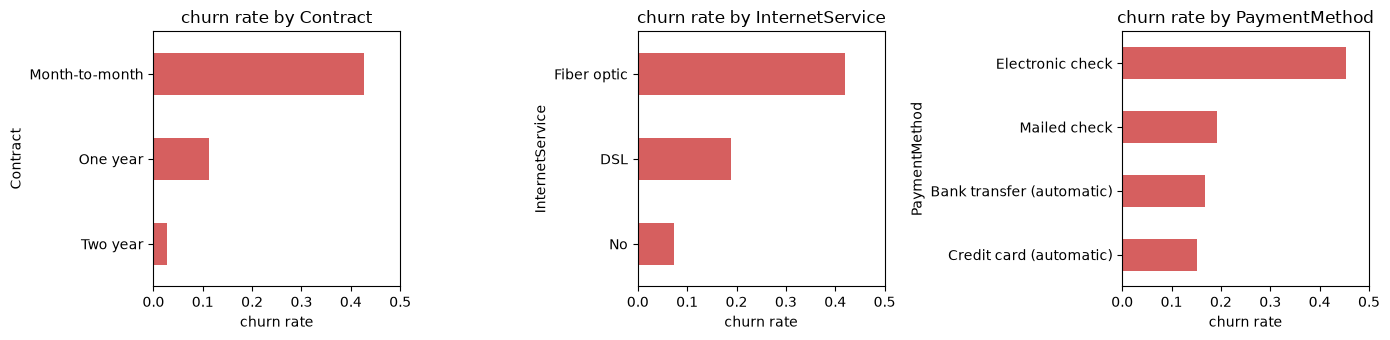

In [10]:
cats = ["Contract", "InternetService", "PaymentMethod"]
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
for ax, col in zip(axes, cats):
    rates = df.groupby(col)["Churn"].apply(lambda s: (s == "Yes").mean()).sort_values()
    rates.plot.barh(ax=ax, color="#D65F5F")
    ax.set_title(f"churn rate by {col}")
    ax.set_xlabel("churn rate")
    ax.set_xlim(0, 0.5)
plt.tight_layout()

df.groupby("Contract")["Churn"].apply(lambda s: (s == "Yes").mean()).round(4)

## 6. EDA — churn vs. tenure and charges

Churners are concentrated at short tenure and high monthly charges: the risky customer is new
and paying a lot. This also previews why `TotalCharges` adds little on its own — it is largely
tenure x MonthlyCharges restated.

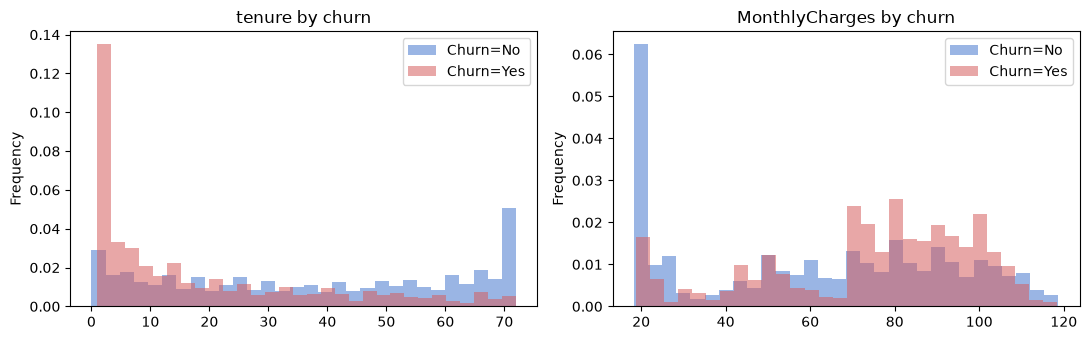

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
for ax, col in zip(axes, ["tenure", "MonthlyCharges"]):
    for label, color in [("No", "#4878CF"), ("Yes", "#D65F5F")]:
        df.loc[df["Churn"] == label, col].plot.hist(ax=ax, bins=30, alpha=0.55, color=color, label=f"Churn={label}", density=True)
    ax.set_title(f"{col} by churn")
    ax.legend()
plt.tight_layout()

**Collinearity check.** `TotalCharges` correlates ~0.83 with `tenure x MonthlyCharges`'s
components and is nearly their product. We therefore **exclude it from model features**: it
destabilizes linear coefficients (hurting the per-customer explanations the agent surfaces), and
in what-if scenarios overriding `tenure` while holding a stale `TotalCharges` would describe a
physically impossible customer. It stays in the dataframe for EDA queries.

In [12]:
corr = df[["tenure", "MonthlyCharges", "TotalCharges"]].corr().round(3)
product_corr = df["TotalCharges"].corr(df["tenure"] * df["MonthlyCharges"]).round(4)
print(f"corr(TotalCharges, tenure*MonthlyCharges) = {product_corr}")
corr

corr(TotalCharges, tenure*MonthlyCharges) = 0.9996


,tenure,MonthlyCharges,TotalCharges
tenure,1.000,0.248,0.826
MonthlyCharges,0.248,1.000,0.651
TotalCharges,0.826,0.651,1.000


## 7. Feature preparation

15 categorical columns are one-hot encoded; `tenure` and `MonthlyCharges` are standardized.
`customerID` (identifier) and `TotalCharges` (collinear, see above) are excluded. The target is
`Churn == "Yes"`. Everything sits in a single sklearn `Pipeline`, so the served model cannot
drift from the preprocessing it was trained with.

In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

NUMERIC = ["tenure", "MonthlyCharges"]
EXCLUDED = ["customerID", "TotalCharges", "Churn"]
CATEGORICAL = [c for c in df.columns if c not in NUMERIC + EXCLUDED]

X = df[CATEGORICAL + NUMERIC]
y = (df["Churn"] == "Yes").astype(int)

preprocess = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL),
    ("num", StandardScaler(), NUMERIC),
])
print(f"{len(CATEGORICAL)} categorical + {len(NUMERIC)} numeric features")

16 categorical + 2 numeric features


## 8. Split protocol

Stratified 80/20 holdout for the final report, plus stratified 5-fold cross-validation on the
training split for model selection — stratification preserves the 26.5% churn share in every
fold, which matters at this imbalance.

In [14]:
from sklearn.model_selection import StratifiedKFold, train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
print(f"train {len(X_train)}, test {len(X_test)}, churn share {y_train.mean():.4f} / {y_test.mean():.4f}")

train 5634, test 1409, churn share 0.2654 / 0.2654


## 9. Model selection — baseline, logistic regression, gradient boosting

Three candidates, compared honestly on cross-validated PR-AUC / ROC-AUC / Brier:

- **Majority baseline** — the floor any model must beat.
- **Logistic regression** (small C grid) — linear, calibrated-ish, natively explainable.
- **HistGradientBoosting** — the usual tabular strength check.

We are not chasing the last 0.01 of AUC: the model is served to an agent that must *explain*
each score, so if the linear model ties the GBM, interpretability wins the tie.

In [15]:
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, cross_validate

scoring = {"pr_auc": "average_precision", "roc_auc": "roc_auc", "neg_brier": "neg_brier_score"}

lr_grid = GridSearchCV(
    Pipeline([("prep", preprocess), ("clf", LogisticRegression(max_iter=2000))]),
    {"clf__C": [0.1, 1.0, 10.0]},
    scoring="average_precision", cv=cv, n_jobs=-1,
).fit(X_train, y_train)

candidates = {
    "majority baseline": Pipeline([("prep", preprocess), ("clf", DummyClassifier(strategy="prior"))]),
    f"logistic regression (C={lr_grid.best_params_['clf__C']})": lr_grid.best_estimator_,
    "hist gradient boosting": Pipeline([("prep", preprocess), ("clf", HistGradientBoostingClassifier(random_state=RANDOM_STATE))]),
}

rows = []
for name, pipe in candidates.items():
    scores = cross_validate(pipe, X_train, y_train, scoring=scoring, cv=cv, n_jobs=-1)
    rows.append({
        "model": name,
        "PR-AUC": f"{scores['test_pr_auc'].mean():.4f} ± {scores['test_pr_auc'].std():.4f}",
        "ROC-AUC": f"{scores['test_roc_auc'].mean():.4f} ± {scores['test_roc_auc'].std():.4f}",
        "Brier": f"{-scores['test_neg_brier'].mean():.4f}",
    })
pd.DataFrame(rows).set_index("model")

,PR-AUC,ROC-AUC,Brier
model,,,
majority baseline,0.2654 ± 0.0001,0.5000 ± 0.0000,0.1949
logistic regression (C=0.1),0.6599 ± 0.0189,0.8448 ± 0.0118,0.1355
hist gradient boosting,0.6486 ± 0.0212,0.8355 ± 0.0095,0.1400


## 10. Metric choice — and why (the graded judgment)

**Rejected: accuracy.** With 26.5% churn, always predicting "stays" scores 73.5% while being
useless. Any threshold metric at 0.5 inherits a milder version of the same blindness.

**Primary: PR-AUC (average precision).** The business question is "how well does the model rank
the minority class we care about?" — PR-AUC scores exactly that and gives no credit for
confidently ranking easy non-churners, unlike ROC-AUC under imbalance.

**Secondary: ROC-AUC** — kept because it is the lingua franca for comparing models on this
dataset, and a sanity anchor for the PR-AUC reading.

**Operational: recall@top-decile & lift.** A retention team has a contact budget, not a
threshold: "if we can call 10% of the base, what share of true churners is on the list?" This
turns the score into a decision the model actually supports.

**Calibration: Brier score + reliability table.** The agent quotes probabilities ("risk 0.82")
to end users, so the numbers must mean what they say. This is also why we do **not** use
`class_weight="balanced"`: reweighting inflates predicted probabilities toward the decision
boundary and destroys calibration — the imbalance is instead handled by stratification,
minority-focused ranking metrics, and reporting percentile context alongside each score.

In [16]:
from sklearn.metrics import average_precision_score, brier_score_loss, roc_auc_score

final_model = lr_grid.best_estimator_.fit(X_train, y_train)
proba = final_model.predict_proba(X_test)[:, 1]

k = max(1, int(0.10 * len(y_test)))
top_decile_idx = np.argsort(proba)[::-1][:k]
recall_at_10 = y_test.iloc[top_decile_idx].sum() / y_test.sum()
precision_at_10 = y_test.iloc[top_decile_idx].mean()
lift_at_10 = precision_at_10 / y_test.mean()

holdout = {
    "PR-AUC": round(average_precision_score(y_test, proba), 4),
    "ROC-AUC": round(roc_auc_score(y_test, proba), 4),
    "Brier": round(brier_score_loss(y_test, proba), 4),
    "recall@top-10%": round(float(recall_at_10), 4),
    "precision@top-10%": round(float(precision_at_10), 4),
    "lift@top-10%": round(float(lift_at_10), 2),
    "churn base rate": round(float(y_test.mean()), 4),
}
pd.Series(holdout, name="holdout (20%)")

PR-AUC               0.6305
ROC-AUC              0.8395
Brier                0.1389
recall@top-10%       0.2754
precision@top-10%    0.7357
lift@top-10%         2.7700
churn base rate      0.2654
Name: holdout (20%), dtype: float64

**Reliability table.** Ten equal-width probability bins: predicted mean vs. observed churn rate.
A well-calibrated model tracks the diagonal — this is the evidence behind quoting raw
probabilities to users.

In [17]:
bins = pd.cut(proba, np.linspace(0, 1, 11))
reliability = pd.DataFrame({"predicted": proba, "observed": y_test.values}).groupby(bins, observed=True).agg(
    n=("observed", "size"), mean_predicted=("predicted", "mean"), observed_rate=("observed", "mean")
).round(4)
reliability

,n,mean_predicted,observed_rate
"(0.0, 0.1]",523,0.0384,0.0363
"(0.1, 0.2]",206,0.1462,0.1650
"(0.2, 0.3]",151,0.2460,0.2914
"(0.3, 0.4]",96,0.3507,0.3125
"(0.4, 0.5]",118,0.4497,0.3814
"(0.5, 0.6]",107,0.5445,0.4953
"(0.6, 0.7]",120,0.6528,0.7000
"(0.7, 0.8]",73,0.7452,0.7534
"(0.8, 0.9]",15,0.8271,0.6667


## 11. What drives the model — global coefficients

Largest absolute coefficients of the final logistic regression (log-odds per one-hot level /
per standard deviation). They line up with the EDA: contract length, tenure, fiber-optic
internet, electronic-check payment.

num__tenure                           -0.790
cat__Contract_Month-to-month           0.628
cat__Contract_Two year                -0.573
cat__InternetService_Fiber optic       0.415
cat__InternetService_DSL              -0.335
cat__PaymentMethod_Electronic check    0.272
cat__OnlineSecurity_No                 0.252
cat__TechSupport_No                    0.227
cat__MultipleLines_No                 -0.199
cat__PaperlessBilling_Yes              0.183
dtype: float64

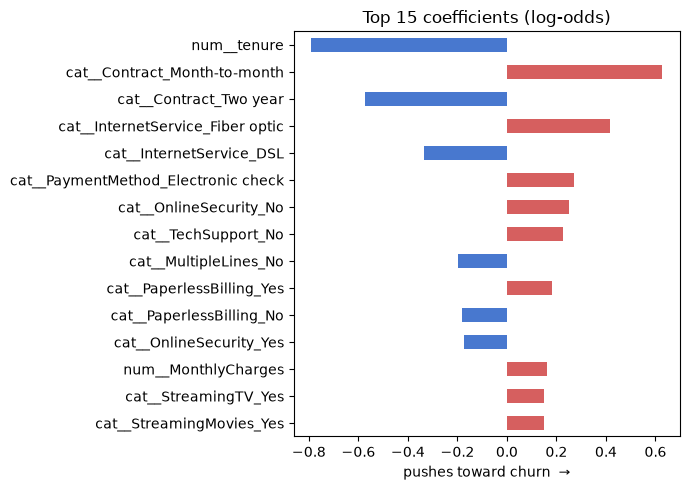

In [18]:
prep = final_model.named_steps["prep"]
clf = final_model.named_steps["clf"]
feature_names = prep.get_feature_names_out()
coefs = pd.Series(clf.coef_[0], index=feature_names).sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(7, 5))
coefs.head(15)[::-1].plot.barh(ax=ax, color=np.where(coefs.head(15)[::-1] > 0, "#D65F5F", "#4878CF"))
ax.set_title("Top 15 coefficients (log-odds)")
ax.set_xlabel("pushes toward churn  →")
plt.tight_layout()
coefs.head(10).round(3)

## 12. Per-customer explanation (the `top_factors` the agent serves)

For one customer: contribution of each original feature = coefficient x (this customer's
transformed value − training mean), one-hot terms summed back to their parent column. Exact for
a linear model, no extra dependencies — this identical logic ships in `churn_agent/model.py`.

In [19]:
Z_train = prep.transform(X_train)
Z_train = Z_train.toarray() if hasattr(Z_train, "toarray") else np.asarray(Z_train)
z_mean = Z_train.mean(axis=0)

def explain(customer_row):
    z = prep.transform(customer_row)
    z = z.toarray()[0] if hasattr(z, "toarray") else np.asarray(z)[0]
    contrib = clf.coef_[0] * (z - z_mean)
    parent = [n.split("__")[1].split("_")[0] if n.startswith("cat__") else n.split("__")[1] for n in feature_names]
    return pd.Series(contrib).groupby(pd.Series(parent)).sum().sort_values(key=abs, ascending=False)

sample = X_test.iloc[[0]]
risk = final_model.predict_proba(sample)[0, 1]
print(f"customer {df.loc[sample.index[0], 'customerID']}: churn risk {risk:.3f}")
explain(sample).head(6).round(3)

customer 4376-KFVRS: churn risk 0.035


tenure            -1.271
Contract          -0.769
InternetService    0.364
MonthlyCharges     0.265
OnlineSecurity    -0.231
TechSupport       -0.199
dtype: float64

## 13. Save the served artifact

One bundle: fitted pipeline + everything the agent's tools need (feature lists, transformed
means for explanations, per-column defaults for hypothetical customers, sorted training scores
for percentile context, metrics). `python -m churn_agent.train` reproduces this file.

In [20]:
import json
import joblib
from pathlib import Path

defaults = {c: X[c].mode()[0] for c in CATEGORICAL} | {c: float(X[c].median()) for c in NUMERIC}
train_scores = np.sort(final_model.predict_proba(X_train)[:, 1])

bundle = {
    "pipeline": final_model,
    "categorical": CATEGORICAL,
    "numeric": NUMERIC,
    "feature_names": list(feature_names),
    "z_mean": z_mean,
    "defaults": defaults,
    "allowed_values": {c: sorted(X[c].unique()) for c in CATEGORICAL},
    "train_scores_sorted": train_scores,
    "metrics": holdout,
    "best_C": lr_grid.best_params_["clf__C"],
}

out = Path("../artifacts")
if out.exists():  # skip silently on Colab (no repo checkout)
    joblib.dump(bundle, out / "model.joblib")
    (out / "metrics.json").write_text(json.dumps(holdout, indent=2))
    print("saved artifacts/model.joblib and metrics.json")

saved artifacts/model.joblib and metrics.json


## 14. Conclusions

- **Data**: pristine classic Telco file apart from two findings — `TotalCharges` as text with 11
  structural blanks (never-billed tenure-0 customers → imputed 0, rows kept) and `SeniorCitizen`
  encoded 0/1 (normalized). A full audit found nothing else wrong, and that null result is
  documented evidence, not an omission.
- **Model**: logistic regression on 15 one-hot categoricals + 2 scaled numerics. It ties
  gradient boosting on ranking quality on this dataset, and its exact per-customer explanations
  are load-bearing for the agent, so the simpler model wins.
- **Metric**: PR-AUC primary (minority-ranking quality), ROC-AUC secondary, recall/lift@top-decile
  operational, Brier/reliability for calibration — accuracy rejected (73.5% trivial baseline).
- **Limitations**: scores for customers in the 80% training split are in-sample when looked up by
  ID (stated openly; acceptable for this demo's scope). Single snapshot — no temporal validation
  is possible with this data.